# 넷플릭스 주가 예측하기 RNN 코드 실습

## 1. 데이터 가져오기

In [7]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/netflix_train.csv')
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (67.8 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direct

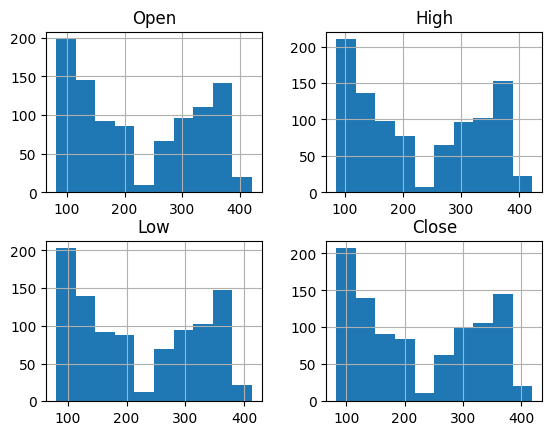

In [10]:
# 데이터 분포를 히스토그램으로 살펴보기
import matplotlib.pyplot as plt

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')


# 개장가, 최고가, 최저가 추가
# 종가 추가
data_used = data[['Open', 'High', 'Low', 'Close']]

hist = data_used.hist()
plt.show()

## 2. 파이토치 데이터셋 구성하기

In [16]:
import numpy as np
from torch.utils.data.dataset import Dataset

class Netflix(Dataset):  # 클래스 선언
   def __init__(self):
     # 데이터 읽기
    self.csv = pd.read_csv('/content/drive/MyDrive/netflix_train.csv')


       # 입력 데이터 정규화
          # 종가를 제외한 데이터
          # 0과 1 사이로 정규화
    input_data = self.csv[['Open', 'High', 'Low', 'Volume']].values.astype(np.float32)
    self.input_min = input_data.min(axis=0)
    self.input_max = input_data.max(axis=0)
    self.input_data = (input_data - self.input_min) / (self.input_max - self.input_min)

       # 종가 데이터 정규화
    close_data = self.csv['Close'].values.astype(np.float32).reshape(-1, 1)
    self.close_min = close_data.min()
    self.close_max = close_data.max()
    self.close_data = (close_data - self.close_min) / (self.close_max - self.close_min)
    self.data = np.concatenate([self.input_data, self.close_data], axis=1)


   def __len__(self):
       return len(self.data) - 30 # 사용 가능한 배치 개수

   def __getitem__(self, i):
        # 입력 데이터 30일치 읽기
        # self.data에는 [Open, High, Low, Volume, Close] 순서로 정규화되어 들어있습니다.
        data = self.data[i : i+30]
        # 종가 데이터 30일치 읽기
        # self.data의 마지막 컬럼(-1)이 종가(Close)입니다.
        label = self.data[i+30, -1]
        return torch.tensor(data), torch.tensor(label)

## 3. RNN 모델 정의

In [19]:
# RNN 클래스 정의

import torch
import torch.nn as nn

class RNN(nn.Module):
   def __init__(self):
       super(RNN, self).__init__()

       # 1. RNN층의 정의
        # input_size: 특징 개수 (Open, High, Low, Volume, Close 총 5개)
        # hidden_size: RNN 내부 결과물의 크기 (예: 8)
        # num_layers: RNN 층의 개수
       self.rnn = nn.RNN(input_size=5, hidden_size=8, num_layers=1, batch_first=True)
       # 주가를 예측하는 MLP층 정의
       # RNN의 hidden_size(8)를 입력받아 최종 종가 1개를 출력
       self.fc = nn.Linear(in_features=8, out_features=1)

       # 활성화 함수 정의
       self.relu = nn.ReLU()

# RNN 모델의 순전파 정의
   def forward(self, x, h0):
         # RNN층의 출력
         # x: (batch_size, 30, 5), h0: 초기 hidden state
         # out은 (batch_size, 30, 8)의 형태가 됨
        x, hn = self.rnn(x, h0)
       # MLP층의 입력으로 사용되게 모양 변경
       # 우리는 30일치 중 '마지막 날'의 출력값만 사용함
      # x[:, -1, :] -> (batch_size, 8)
        x = x[:, -1, :]

       # MLP층을 이용해 종가 예측
        x = self.relu(x)
        x = self.fc(x)

       # 예측한 종가를 1차원 벡터로 표현
       # (batch_size, 1) -> (batch_size)
        x = torch.reshape(x, (-1,))
        return x

## 4. 모델 학습하기

In [20]:
# 모델과 데이터셋 정의
import tqdm
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

  # 모델의 정의
model = RNN().to(device)
      # 데이터셋의 정의
dataset = Netflix()

In [21]:
# 데이터로더 정의
  # 배치 크기를 32로 설정
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [23]:
# 최적화 정의
# 학습률은 0.0001로 설정
 # 사용할 최적화 설정
lr = 0.0001
optim = Adam(params=model.parameters(), lr=lr)

In [26]:
# 학습 루프 정의
# 에포크: 200
for epoch in range(200):
   iterator = tqdm.tqdm(loader)
   for data, label in iterator:
       optim.zero_grad()

       # 초기 은닉 상태
       h0 = torch.zeros(1, data.shape[0], 8).to(device)

       # 모델의 예측값
       predict = model(data.to(device), h0)

       # 손실의 계산
       loss = nn.MSELoss()(predict, label.to(device))
         # 오차 역전파
       loss.backward()
         # 최적화 진행
       optim.step()
       iterator.set_description(f"epoch{epoch} loss:{loss.item()}")

  # 모델 저장
torch.save(model.state_dict(), "netflix_rnn.pth")

epoch199 loss:0.0007628344465047121: 100%|██████████| 30/30 [00:00<00:00, 143.57it/s]


## 5. 모델 성능 평가하기

In [27]:
import matplotlib.pyplot as plt

  # 예측값을 위한 데이터로더
loader = DataLoader(dataset, batch_size=32, shuffle=False)
  # 예측값들을 저장하는 리스트
preds = []
total_loss = 0

with torch.no_grad():
   # 모델의 가중치 불러오기
   model.load_state_dict(torch.load("netflix_rnn.pth", map_location=device))
   model.eval() # 모델을 평가 모드로 전환

   for data, label in loader:
       # 초기 은닉 상태 정의
       h0 = torch.zeros(1, data.shape[0], 8).to(device)
       # 모델의 예측값 출력
       predict = model(data.to(device), h0)
       # 예측값을 리스트에 추가
       preds.extend(predict.cpu().numpy())
       # 손실 계산
       loss = nn.MSELoss()(predict, label.to(device))
       # 손실의 평균치 계산
       total_loss += loss

total_loss.item()

0.02432396449148655

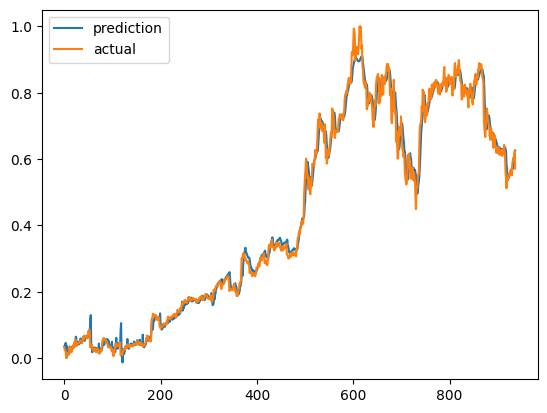

In [29]:
# 그래프 출력
plt.plot(preds, label="prediction")
plt.plot(dataset.close_data[30:], label="actual")
plt.legend()
plt.show()